In [3]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

In [4]:
infile = xr.open_dataset('D:/data/ibtracs/IBTrACS.WP.v04r01.nc')


# In[4]:


stayyy=1949
endyyy=2024
censea=infile['season']
indsea=np.where((censea>=stayyy)&(censea<=endyyy))
numsea=censea[indsea]


# In[5]:


tim=infile['time']
centim=tim.dt.month[:,0]
indtim=np.where((centim==7)|(centim==8)|(centim==9)|(centim==10))
numtim=tim[indtim]


# In[6]:


centyp=infile['track_type']
indtyp=np.where(centyp==b'main')
numtyp=centyp[indtyp]


# In[7]:


cenlat=infile['usa_lat']
nummia=np.sum(np.isnan(cenlat), axis=1)
numnma=np.sum(~np.isnan(cenlat), axis=1)  
minlat=np.amin(cenlat, axis=1)
minlat=np.amin(cenlat, axis=1)
indlat=np.where(numnma>=16)
numlat=cenlat[indlat]


# In[8]:


cenlon=infile['usa_lon']
nummio=np.sum(np.isnan(cenlon), axis=1) 
numnmo=np.sum(~np.isnan(cenlon), axis=1)  
minlon=np.amin(cenlon, axis=1)  
maxlon=np.amax(cenlon, axis=1) 
indlon=np.where(numnmo>=16)
numlon=cenlon[indlon]


# In[9]:


cenwin=infile['usa_wind']
nummiw=np.sum(np.isnan(cenwin), axis=1)   #每行nan个数
numnmw=np.sum(~np.isnan(cenwin), axis=1)  
maxwin = np.amax(cenwin, axis=1) 
indmaw = np.where(maxwin>=35) 
indwin = np.where((numnmw>=16)&(maxwin>=35))
numwin =cenwin[indwin]
# numwin


# In[10]:


cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
numb=np.sum(cenatu != b'', axis=1)#非空值的个数，用于去除空值以及小于48小时的情况,numb>16,3h
indnat=np.where((numb!=numnat)&(numb>16))


# In[11]:


lat = infile['usa_lat']

# 创建布尔掩码以筛选7、8、9月份的数据
mask = lat['time'].dt.month.isin([7, 8, 9])

# 保留掩码对应的数据并将其他数据设为NaN
lat2 = lat.where(mask, drop=True)

# 打印筛选后的数据以检查结果
# print(lat2)


# ## 登陆landindall_flat

# In[12]:


cendis=infile['dist2land']
nummid=np.sum(np.isnan(cendis), axis=1)   
numnmd=np.sum(~np.isnan(cendis), axis=1)  #非nan数
num0md=np.sum(cendis==0, axis=1) #每行几个0
inddis=np.where((numnmd>=16)&(num0md>0))  #0代表登陆，看有几个0
numdis=cendis[inddis]#登录的结果
landindall=[]
landindallin=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16))
                    &((numnmd>=16)&(num0md>0)))
    landindall.append(indall[0])
landindall_flat = np.concatenate(landindall).tolist()  # 将所有数组拼接并转换为列表


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=12, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


In [6]:
years = np.arange(1982, 2024)
split_index=17

In [7]:
# df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
# id1 = df['Typhoon ID']
# idyr = df['year']
# oriloclat = df['toendlat']
# oriloclon = df['toendlon']

# # 分成两个时期的数据
# df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
# df_period2 = df[(df['year'] >= 2000) & (df['year'] <= 2023)]

In [8]:
# df_period1_inside_box = df_period1[(df_period1['toendlon'] >= lon_min) & (df_period1['toendlon'] <= lon_max) &
#                                    (df_period1['toendlat'] >= lat_min) & (df_period1['toendlat'] <= lat_max)]

# df_period2_inside_box = df_period2[(df_period2['toendlon'] >= lon_min) & (df_period2['toendlon'] <= lon_max) &
#                                    (df_period2['toendlat'] >= lat_min) & (df_period2['toendlat'] <= lat_max)]

# # 打印结果
# print(f"1982-1997 年的数据总量: {df_period1.shape[0]}")
# print(f"1998-2023 年的数据总量: {df_period2.shape[0]}")
# print(f"1982-1997 年框内数据量: {df_period1_inside_box.shape[0]}")
# print(f"1998-2023 年框内数据量: {df_period2_inside_box.shape[0]}")

# # 进行卡方检验或 z 检验
# from scipy import stats
# observed = [[df_period1_inside_box.shape[0], df_period1.shape[0] - df_period1_inside_box.shape[0]],
#             [df_period2_inside_box.shape[0], df_period2.shape[0] - df_period2_inside_box.shape[0]]]

# # 进行卡方检验
# chi2, p_value, dof, expected = stats.chi2_contingency(observed)

# # 打印检验结果
# print(f"卡方值: {chi2}, p值: {p_value}")

# if p_value < 0.05:
#     print("两个时期框内台风数量之间存在显著差异。")
# else:
#     print("两个时期框内台风数量之间不存在显著差异。")


In [9]:
# df_period1_landfall = df_period1[df_period1['Typhoon ID'].isin(landindall_flat)]
# df_period2_landfall = df_period2[df_period2['Typhoon ID'].isin(landindall_flat)]

# # 统计框内的登陆台风数据
# df_period1_landfall_inside_box = df_period1_landfall[(df_period1_landfall['toendlon'] >= lon_min) & (df_period1_landfall['toendlon'] <= lon_max) &
#                                                      (df_period1_landfall['toendlat'] >= lat_min) & (df_period1_landfall['toendlat'] <= lat_max)]

# df_period2_landfall_inside_box = df_period2_landfall[(df_period2_landfall['toendlon'] >= lon_min) & (df_period2_landfall['toendlon'] <= lon_max) &
#                                                      (df_period2_landfall['toendlat'] >= lat_min) & (df_period2_landfall['toendlat'] <= lat_max)]

# # 打印结果
# print(f"1982-1997 年登陆台风总量: {df_period1_landfall.shape[0]}")
# print(f"1998-2023 年登陆台风总量: {df_period2_landfall.shape[0]}")
# print(f"1982-1997 年框内登陆台风数量: {df_period1_landfall_inside_box.shape[0]}")
# print(f"1998-2023 年框内登陆台风数量: {df_period2_landfall_inside_box.shape[0]}")

# # 进行卡方检验或 z 检验，比较框内的登陆台风数量是否存在显著差异
# observed_landfall = [[df_period1_landfall_inside_box.shape[0], df_period1_landfall.shape[0] - df_period1_landfall_inside_box.shape[0]],
#                      [df_period2_landfall_inside_box.shape[0], df_period2_landfall.shape[0] - df_period2_landfall_inside_box.shape[0]]]

# # 进行卡方检验
# chi2_landfall, p_value_landfall, dof_landfall, expected_landfall = stats.chi2_contingency(observed_landfall)

# # 打印检验结果
# print(f"登陆台风的卡方值: {chi2_landfall}, p值: {p_value_landfall}")

# if p_value_landfall < 0.05:
#     print("两个时期框内登陆台风数量之间存在显著差异。")
# else:
#     print("两个时期框内登陆台风数量之间不存在显著差异。")


1982-1998年平均纬度: 37.40693650218104, 经度: 145.49248575199547
1999-2023年平均纬度: 37.778787918421095, 经度: 143.45497791901295
纬度的t检验统计量: -0.5520973656170441, p值: 0.5812907210918806
经度的t检验统计量: 1.2301546705023911, p值: 0.2195112557916337


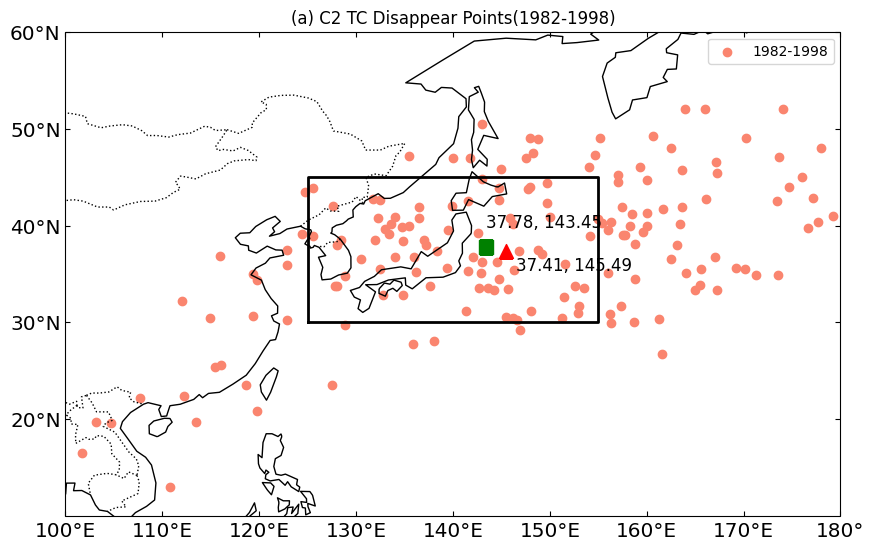

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
import cartopy.mpl.ticker as cticker
# 加载数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
id1 = df['Typhoon ID']
idyr = df['year']
oriloclat = df['toendlat']
oriloclon = df['toendlon']

# 分成两个时期的数据
df_period1 = df[(df['year'] >= 1982) & (df['year'] <= 1998)]
df_period2 = df[(df['year'] >= 2000) & (df['year'] <= 2023)]

# 计算两个时期的经纬度平均值
mean_lat_period1 = df_period1['toendlat'].mean()
mean_lon_period1 = df_period1['toendlon'].mean()

mean_lat_period2 = df_period2['toendlat'].mean()
mean_lon_period2 = df_period2['toendlon'].mean()

print(f"1982-1998年平均纬度: {mean_lat_period1}, 经度: {mean_lon_period1}")
print(f"1999-2023年平均纬度: {mean_lat_period2}, 经度: {mean_lon_period2}")

# 执行t检验，检验两个时期的台风起点纬度的显著性差异
t_stat_lat, p_value_lat = stats.ttest_ind(df_period1['toendlat'], df_period2['toendlat'], equal_var=False)
t_stat_lon, p_value_lon = stats.ttest_ind(df_period1['toendlon'], df_period2['toendlon'], equal_var=False)

print(f"纬度的t检验统计量: {t_stat_lat}, p值: {p_value_lat}")
print(f"经度的t检验统计量: {t_stat_lon}, p值: {p_value_lon}")

# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(20, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(20, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    # 选择颜色和标签
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())

# 添加图例
ax.legend(loc='upper right')

# 在图中标出两个时期的平均值，并用三角形和正方形表示
# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1 - 2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2 + 2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='k', transform=ccrs.PlateCarree(),linewidth=2,)

plt.title('(a) C2 TC Disappear Points(1982-1998)')
plt.show()


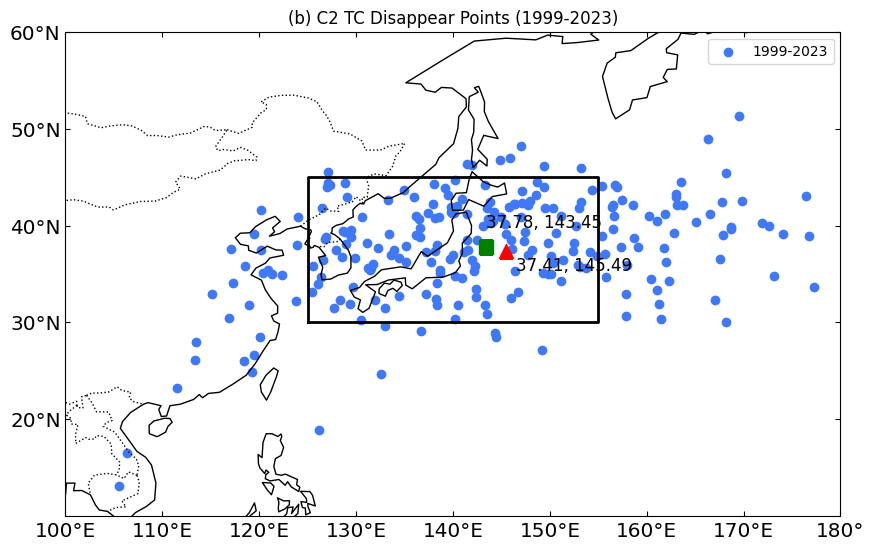

In [11]:
# 设置地图和特征
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(100, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(20, 61, 10), crs=ccrs.PlateCarree())
# ax.set_xticks([0,20,40,60]) # 设置刻度
ax.set_xticklabels(np.arange(100, 181, 10),fontsize = 'x-large') # 设置刻度标签
ax.set_yticklabels(np.arange(20, 61, 10),fontsize = 'x-large') # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

# 标记是否已添加图例
added_legend = {'1982-1998': False, '1999-2023': False}

# 绘制台风的起点，根据年份使用不同颜色
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度

    if 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())

# 添加图例
ax.legend(loc='upper right')
# 在图中标出两个时期的平均值，并用三角形和正方形表示

# 标出1982-1998年时期的平均值
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=12, transform=ccrs.Geodetic())

# 标出1999-2023年时期的平均值
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=12, transform=ccrs.Geodetic())

extent = [125, 155, 30, 45]
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='black', transform=ccrs.PlateCarree(),linewidth=2,)

# extent = [105, 125, 20, 30]
# ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
#         [extent[2], extent[2], extent[3], extent[3], extent[2]], 
#         color='black', transform=ccrs.PlateCarree(),linewidth=2,)

# extent = [105, 115, 20, 25]
# ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
#         [extent[2], extent[2], extent[3], extent[3], extent[2]], 
#         color='black', transform=ccrs.PlateCarree(),linewidth=2,)
# 设置标题和显示图形
plt.title('(b) C2 TC Disappear Points (1999-2023)')
plt.show()


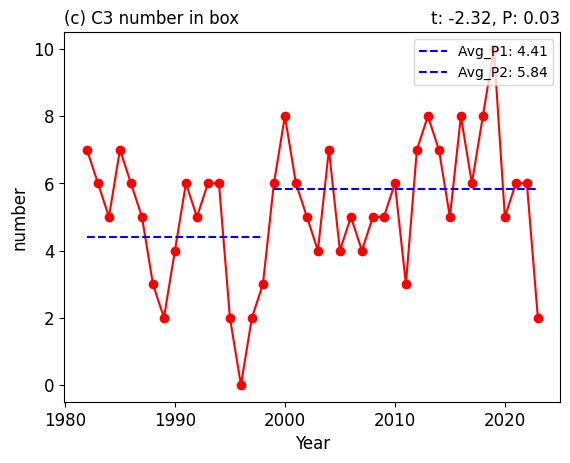

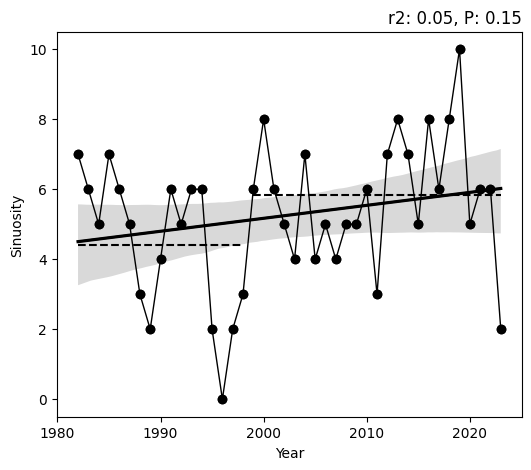

R: 0.2256920751843144
P: 0.15068137608886198
R2: 0.05093691280100222


In [12]:
#框内数量
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 定义框的经纬度范围
lon_min, lon_max = 125, 155
lat_min, lat_max = 30, 45

# 1982-2023年所有数据
df_period = df[(df['year'] >= 1982) & (df['year'] <= 2023)]

# 统计每年框内的台风数量
def count_typhoons_in_box(df, lon_min, lon_max, lat_min, lat_max):
    # 过滤框内的台风数据
    df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                       (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)]
    
    # 统计每年框内的台风数量
    typhoon_count_per_year = df_inside_box.groupby('year').size()
    
    return typhoon_count_per_year

# 获取每年框内的台风数量
typhoon_count = count_typhoons_in_box(df_period, lon_min, lon_max, lat_min, lat_max)

# 将没有台风数据的年份填充为0
years = list(range(1982, 2024))
typhoon_count = typhoon_count.reindex(years, fill_value=0)

plot_change_data(years, typhoon_count, 'number', '(c) C3 number in box', 17)

box_c2=typhoon_count

#框内占比
# c2_per=box_c2/c2totalnumber
# plot_change_data(years, c2_per, 'number', ' per number(C3)', 17)

x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=box_c2
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
split_index=17
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

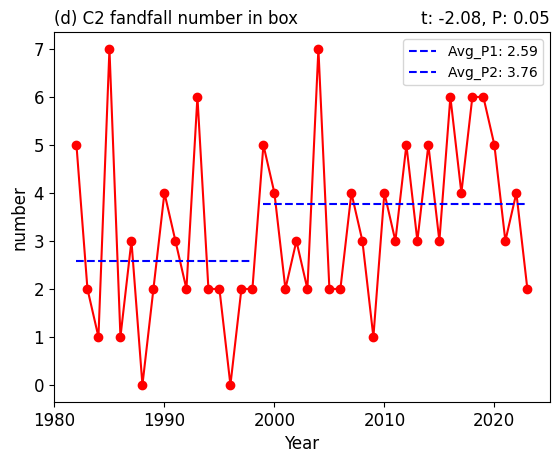

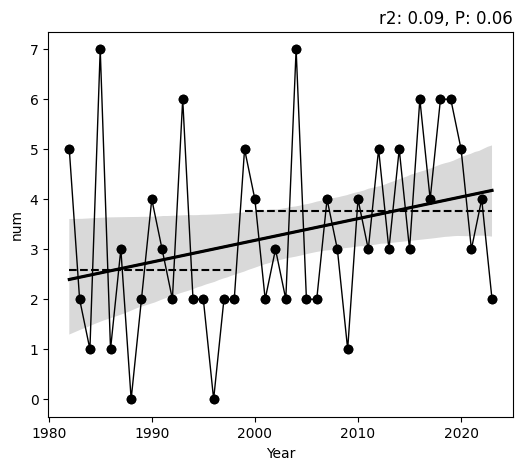

R: 0.29631227821568645
P: 0.05672715190564883
R2: 0.08780096622137037


In [13]:
#框内数量
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 定义框的经纬度范围
lon_min, lon_max = 125, 155
lat_min, lat_max = 30, 45

# 1982-2023年所有数据
df_period = df[(df['year'] >= 1982) & (df['year'] <= 2023)]

# 统计每年框内的台风数量
def count_typhoons_in_box(df, lon_min, lon_max, lat_min, lat_max):
    # 过滤框内的台风数据
    df_inside_box = df[(df['toendlon'] >= lon_min) & (df['toendlon'] <= lon_max) &
                       (df['toendlat'] >= lat_min) & (df['toendlat'] <= lat_max)&
                        (df['Typhoon ID'].isin(landindall_flat))
                      ]
    
    # 统计每年框内的台风数量
    typhoon_count_per_year = df_inside_box.groupby('year').size()
    
    return typhoon_count_per_year

# 获取每年框内的台风数量
typhoon_count = count_typhoons_in_box(df_period, lon_min, lon_max, lat_min, lat_max)

# 将没有台风数据的年份填充为0
years = list(range(1982, 2024))
typhoon_count = typhoon_count.reindex(years, fill_value=0)

plot_change_data(years, typhoon_count, 'number', '(d) C2 fandfall number in box', 17)

box_c2_land=typhoon_count



x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=box_c2_land
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('num')
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
split_index=17
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])

# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

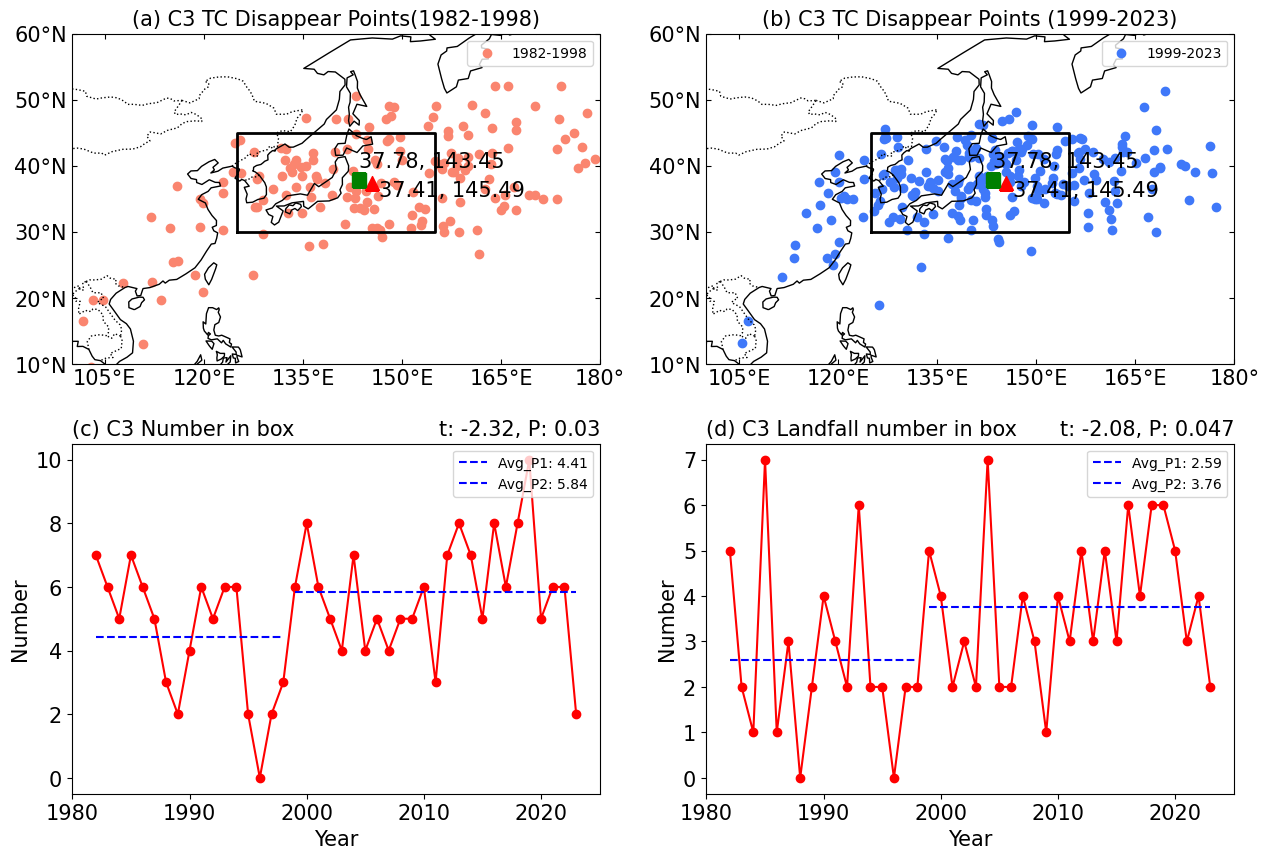

In [14]:
fig=plt.figure(figsize=(15,10))
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax=ax1
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
added_legend = {'1982-1998': False, '1999-2023': False}
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度
    if 1982 <= year <= 1998:
        color = '#fa856f'
        label = '1982-1998'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())
ax.legend(loc='upper right')
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1 - 2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=15, transform=ccrs.Geodetic())
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2 + 2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=15, transform=ccrs.Geodetic())
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='k', transform=ccrs.PlateCarree(),linewidth=2,)
ax.set_title('(a) C3 TC Disappear Points(1982-1998)',fontsize=15)

ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax=ax2
ax.set_extent([100, 180, 10, 50])  # 设置地图的经纬度范围
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True,direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15),fontsize = 15) # 设置刻度标签
ax.set_yticklabels(np.arange(10, 61, 10),fontsize = 15) # 设置刻度标签
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
added_legend = {'1982-1998': False, '1999-2023': False}
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    lat = oriloclat[i]  # 使用台风起点纬度
    lon = oriloclon[i]  # 使用台风起点经度
    if 1999 <= year <= 2023:
        color =  '#3f78f9'
        label = '1999-2023'
        if not added_legend[label]:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic(), label=label)
            added_legend[label] = True
        else:
            ax.scatter(lon, lat, color=color, transform=ccrs.Geodetic())
ax.legend(loc='upper right')
ax.scatter(mean_lon_period1, mean_lat_period1, color='r', marker='^', s=100, label=f'1982-1998 Avg ({mean_lat_period1:.2f}, {mean_lon_period1:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period1 + 1, mean_lat_period1-2, f'{mean_lat_period1:.2f}, {mean_lon_period1:.2f}', fontsize=15, transform=ccrs.Geodetic())
ax.scatter(mean_lon_period2, mean_lat_period2, color ='g', marker='s', s=100, label=f'1999-2023 Avg ({mean_lat_period2:.2f}, {mean_lon_period2:.2f})', transform=ccrs.Geodetic())
ax.text(mean_lon_period2 , mean_lat_period2+2, f'{mean_lat_period2:.2f}, {mean_lon_period2:.2f}', fontsize=15, transform=ccrs.Geodetic())
ax.plot([extent[0], extent[1], extent[1], extent[0], extent[0]], 
        [extent[2], extent[2], extent[3], extent[3], extent[2]], 
        color='black', transform=ccrs.PlateCarree(),linewidth=2,)
ax.set_title('(b) C3 TC Disappear Points (1999-2023)',fontsize=15)


ax3 = fig.add_subplot(2, 2, 3)
ax=ax3
split_index=17
data=box_c2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(c) C3 Number in box',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax4 = fig.add_subplot(2, 2, 4)
ax=ax4
data=box_c2_land
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(d) C3 Landfall number in box',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.3f}',loc='right',fontsize=15)

plt.show()

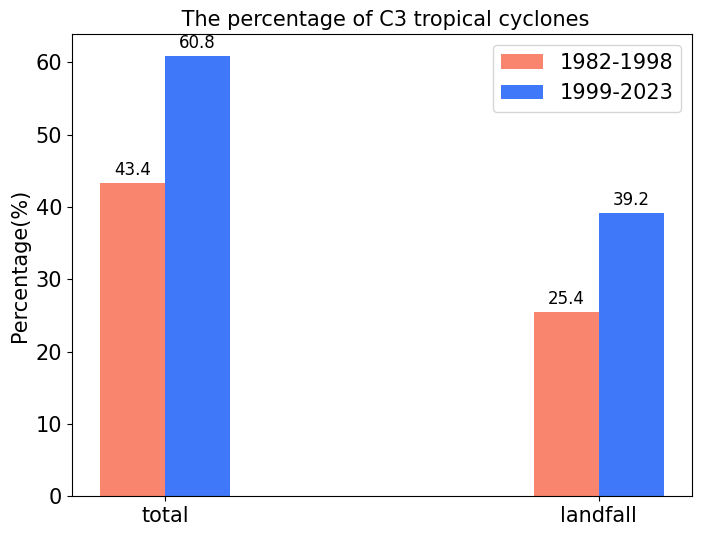

In [15]:
import numpy as np
import matplotlib.pyplot as plt
p1=75/173*100
p1land=44/173*100
p2=146/240*100
p2land=94/240*100
# 示例数据
types = ('total','landfall')
buy_number_male = [p1,p1land]  # P1
buy_number_female = [p2,p2land]  # P2

bar_width = 0.15  # 条形宽度
index_male = np.arange(len(types))  # 男生条形图的横坐标
index_female = index_male + bar_width  # 女生条形图的横坐标

# 创建图表和坐标轴对象
fig, ax = plt.subplots(figsize=(8, 6))
bars_male = ax.bar(index_male, height=buy_number_male, width=bar_width, color='#fa856f', label='1982-1998')
bars_female = ax.bar(index_female, height=buy_number_female, width=bar_width, color='#3f78f9', label='1999-2023')
ax.bar_label(bars_male, fmt='%.1f', padding=3,fontsize=12)
ax.bar_label(bars_female, fmt='%.1f', padding=3,fontsize=12)
plt.legend(loc=1,fontsize=15)  # 显示图例
plt.xticks(index_male + bar_width/2, types,fontsize=15)  # 设置横坐标轴刻度
plt.ylabel('Percentage(%)',fontsize=15)  # 纵坐标轴标题
plt.tick_params(axis='y', labelsize=15)
plt.title(' The percentage of C3 tropical cyclones',fontsize=15)  # 图形标题

# 显示图表
plt.show()


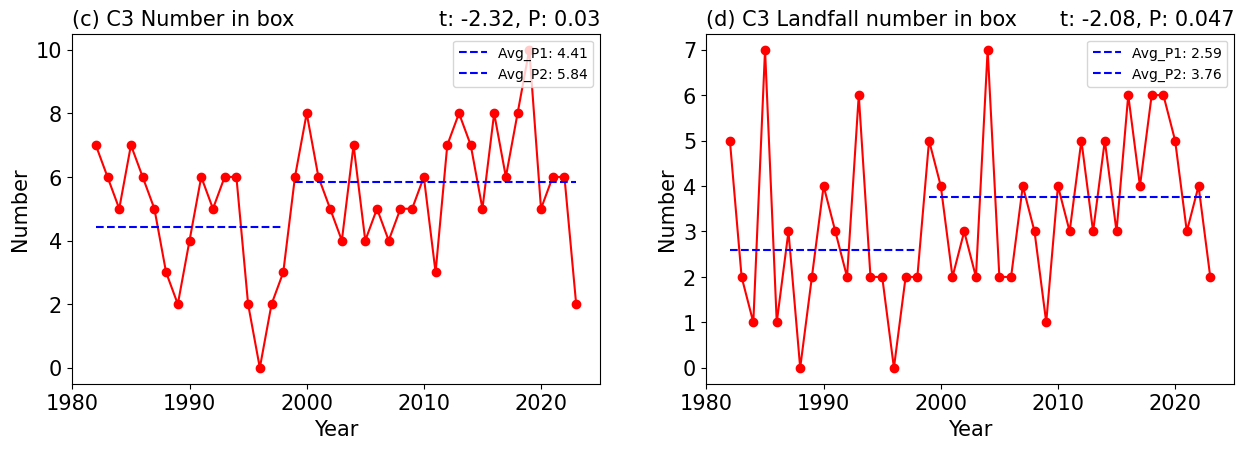

In [16]:
fig=plt.figure(figsize=(15,10))



ax3 = fig.add_subplot(2, 2, 3)
ax=ax3
split_index=17
data=box_c2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(c) C3 Number in box',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)

ax4 = fig.add_subplot(2, 2, 4)
ax=ax4
data=box_c2_land
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color='red')
ax.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('(d) C3 Landfall number in box',loc='left',fontsize=15)
ax.set_title(f't: {t_stat:.2f}, P: {p_value:.3f}',loc='right',fontsize=15)

plt.show()

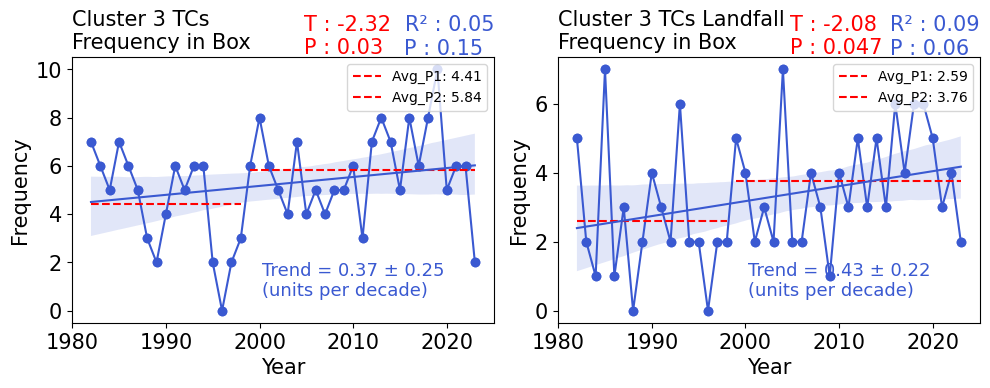

In [17]:
fig=plt.figure(figsize=(10,4))
color1='#3A59D1'
color2=color1
color3='r'


ax2 = fig.add_subplot(1,2,1)
ax=ax2
data=box_c2.values

avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
# ax.set_xlabel('Year', fontsize=15)
# ax.set_ylabel('Number', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Cluster 3 TCs \nFrequency in Box',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.45,0.1,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.55, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='left', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




ax3 = fig.add_subplot(1,2, 2)
ax=ax3
data=box_c2_land.values
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Frequency', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Cluster 3 TCs Landfall \nFrequency in Box',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.45,0.1,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.55, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.3f}', ha='left', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




plt.tight_layout()
plt.savefig("Figure S9.pdf",transparent = True)
plt.show()

In [18]:
box_c2.values

array([ 7,  6,  5,  7,  6,  5,  3,  2,  4,  6,  5,  6,  6,  2,  0,  2,  3,
        6,  8,  6,  5,  4,  7,  4,  5,  4,  5,  5,  6,  3,  7,  8,  7,  5,
        8,  6,  8, 10,  5,  6,  6,  2])

In [19]:
box_c2_land.values

array([5, 2, 1, 7, 1, 3, 0, 2, 4, 3, 2, 6, 2, 2, 0, 2, 2, 5, 4, 2, 3, 2,
       7, 2, 2, 4, 3, 1, 4, 3, 5, 3, 5, 3, 6, 4, 6, 6, 5, 3, 4, 2])